# Species comparison
## Gene pair analysis - lncRNA and TF conservation
### Author: Martin Loza
### Date: 26/01/14
We will investigate the conservation of gene pairs (lncRNA-TF) across species by checking if both the ncRNA and TF have orthologs in other species.

In [64]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
    library(dplyr)
    library(ggalluvial)
})

# Local variables 
seed = 777
date = "260114"

# Define colors for strand plots
red = "#E41A1C"
blue = "#377EB8"
# Define colors for gene types
green = "#4DAF4A"
dark_green = "#2B7A0B"
purple = "#984EA3"
orange = "#FF7F00"
dark_orange = "#A65628"
# Colors for gene pairs
violet = "#9370DB"
dark_violet = "#663399"
text_size = 18
width = 18.6
height = 5
dot_size = 4
line_size = 1.5
dpi = 300

regions_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Liftover/"
supplementary_folder "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Supplementary/"
pairs_file = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Supplementary/Supplementary_Table_lncRNA_TF_pairs_10kb_260109.tsv"
out_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/04_Figure_window_size_and_GO/06_Species_comparison_lncRNA_TF/Plots/"

# Local Functions

# Function to create conservation data for gene pairs
create_gene_pair_conservation <- function(lncRNA_conservation, TF_conservation, gene_pairs) {
    # Ensure we have both lncRNA and TF conservation data
    if (is.null(lncRNA_conservation) || is.null(TF_conservation)) {
        return(NULL)
    }
    
    lncRNA_data <- lncRNA_conservation$data
    TF_data <- TF_conservation$data
    
    # Filter gene pairs to only those present in both conservation datasets
    gene_pairs_filtered <- gene_pairs %>%
        filter(ncRNA_id %in% lncRNA_data$region & pcg_id %in% TF_data$region)
    
    cat(paste0("Gene pairs after filtering: ", nrow(gene_pairs_filtered), "\n"))
    
    # Get species columns (excluding 'region' column)
    species_cols <- setdiff(names(lncRNA_data), "region")
    
    # Create conservation data for gene pairs
    # A gene pair is considered conserved in a species if BOTH lncRNA and TF are present
    pair_conservation <- data.frame(
        pair_id = paste(gene_pairs_filtered$ncRNA_id, gene_pairs_filtered$pcg_id, sep = "_"),
        ncRNA_id = gene_pairs_filtered$ncRNA_id,
        pcg_id = gene_pairs_filtered$pcg_id,
        stringsAsFactors = FALSE
    )
    
    # For each species, check if both lncRNA and TF are present
    for (sp in species_cols) {
        lncRNA_present <- lncRNA_data %>%
            select(region, all_of(sp)) %>%
            rename(ncRNA_id = region, lncRNA_status = all_of(sp))
        
        TF_present <- TF_data %>%
            select(region, all_of(sp)) %>%
            rename(pcg_id = region, TF_status = all_of(sp))
        
        pair_conservation <- pair_conservation %>%
            left_join(lncRNA_present, by = "ncRNA_id") %>%
            left_join(TF_present, by = "pcg_id") %>%
            mutate(
                !!sp := ifelse(lncRNA_status == "Present" & TF_status == "Present", 
                              "Present", "Absent")
            ) %>%
            select(-lncRNA_status, -TF_status)
    }
    
    # Remove ncRNA_id and pcg_id columns for the final conservation data
    pair_conservation_clean <- pair_conservation %>%
        select(-ncRNA_id, -pcg_id) %>%
        rename(region = pair_id)
    
    return(list(
        data = pair_conservation_clean,
        reference = lncRNA_conservation$reference,
        gene_type = "gene_pair"
    ))
}

# Create a conservation matrix for each gene type (lncRNA and TF)
# We'll track whether each region from human has an ortholog in other species

# Function to create conservation data
create_conservation_data <- function(regions_list, gene_type) {
    # Get all species for this gene type
    species_data <- regions_list[grepl(paste0("_", gene_type), names(regions_list))]
    
    if (length(species_data) == 0) {
        return(NULL)
    }
    
    # Extract species names
    species_names <- sapply(names(species_data), function(x) {
        str_split(x, "_")[[1]][1]
    })
    
    # Human is the reference (or first species)
    ref_idx <- which(species_names == "human")
    if (length(ref_idx) == 0) {
        ref_idx <- 1  # Use first species as reference if no human
    }
    
    reference_species <- species_names[ref_idx]
    reference_data <- species_data[[ref_idx]]
    reference_regions <- reference_data$name
    
    # Create a matrix to track conservation
    conservation_df <- data.frame(
        region = reference_regions,
        stringsAsFactors = FALSE
    )
    
    # Add reference species first (all will be "Present")
    conservation_df[[reference_species]] <- "Present"
    
    # For each non-reference species, check if the region is present
    for (i in seq_along(species_data)) {
        sp_name <- species_names[i]
        
        # Skip the reference species since we already added it
        if (sp_name == reference_species) {
            next
        }
        
        sp_regions <- species_data[[i]]$name
        
        # Create a column indicating presence/absence
        conservation_df[[sp_name]] <- ifelse(
            conservation_df$region %in% sp_regions,
            "Present",
            "Absent"
        )
    }
    
    return(list(
        data = conservation_df,
        reference = reference_species,
        gene_type = gene_type
    ))
}

# Prepare data for alluvial plots
prepare_alluvial_data <- function(conservation_result) {
    if (is.null(conservation_result)) {
        return(NULL)
    }
    
    df <- conservation_result$data
    
    # Count the frequency of each conservation pattern
    # We'll aggregate by all species columns (excluding region column)
    species_cols <- setdiff(names(df), "region")
    
    # Count patterns
    pattern_counts <- df %>%
        group_by(across(all_of(species_cols))) %>%
        summarise(Freq = n(), .groups = "drop") 
    
    return(pattern_counts)
}



# Function to create alluvial plot
create_alluvial_plot <- function(alluvial_data, gene_type, species_order = NULL) {
    if (is.null(alluvial_data) || nrow(alluvial_data) == 0) {
        cat(paste0("No data available for ", gene_type, "\n"))
        return(NULL)
    }
    
    # Get species columns (all except Freq)
    species_cols <- setdiff(names(alluvial_data), "Freq")
    
    # Reorder species if specified, otherwise order by conservation level
    if (!is.null(species_order)) {
        species_cols <- intersect(species_order, species_cols)
    } else {
        # Calculate conservation percentage for each species (excluding human)
        other_species <- setdiff(species_cols, "human")
        
        if (length(other_species) > 0) {
            conservation_pct <- sapply(other_species, function(sp) {
                sum((alluvial_data[[sp]] == "Present") * alluvial_data$Freq) / sum(alluvial_data$Freq)
            })
            
            # Order species by conservation percentage (descending)
            ordered_species <- other_species[order(conservation_pct, decreasing = TRUE)]
            
            # Place human first, then ordered species
            if ("human" %in% species_cols) {
                species_cols <- c("human", ordered_species)
            } else {
                species_cols <- ordered_species
            }
        } else if ("human" %in% species_cols) {
            species_cols <- c("human")
        }
    }
    
    # Create new status columns with three levels: "Conserved in all", "Present", "Absent"
    # For patterns conserved in all species, replace "Present" with "Conserved in all"
    for (sp in species_cols) {
        alluvial_data[[sp]] <- as.character(alluvial_data[[sp]])
    }
    
    # Identify patterns conserved in all species
    conserved_all_rows <- apply(alluvial_data[, species_cols, drop = FALSE], 1, function(row) {
        all(row == "Present")
    })
    
    # Replace "Present" with "Ortholog all species" for conserved patterns
    for (sp in species_cols) {
        alluvial_data[[sp]][conserved_all_rows] <- "Ortholog all species"
    }
    
    # Build the aesthetic mapping dynamically
    aes_mapping <- list(y = quote(Freq))
    for (i in seq_along(species_cols)) {
        axis_name <- paste0("axis", i)
        aes_mapping[[axis_name]] <- as.name(species_cols[i])
    }
    
    # Set colors based on gene type
    if (gene_type == "lncRNA") {
        color_ortholog_all <- dark_orange
        color_ortholog <- orange
    } else if (gene_type == "TF") {
        # For TF, use green colors
        color_ortholog_all <- dark_green  # Darker green
        color_ortholog <- green
    } else {
        # For gene pairs, use purple/violet colors
        color_ortholog_all <- dark_violet
        color_ortholog <- violet
    }
    
    # Create the plot with single flow layer colored by destination
    p <- ggplot(alluvial_data, do.call(aes, aes_mapping)) +
        geom_flow(aes(fill = after_stat(stratum)), width = 1/4, alpha = 0.7) +
        geom_stratum(aes(fill = after_stat(stratum)), width = 1/4, color = "grey30", alpha = 1) +
        scale_fill_manual(
            values = c("Ortholog all species" = color_ortholog_all, "Present" = color_ortholog, "Absent" = "grey70"),
            breaks = c("Ortholog all species", "Present", "Absent"),
            labels = c("Ortholog all species", "Ortholog", "Non-ortholog"),
            guide = guide_legend(nrow = 1, byrow = TRUE)
        ) +
        scale_x_discrete(
            limits = species_cols, 
            expand = c(.05, .05),
            labels = function(x) ifelse(x == "elegans", "C. elegans", x)
        ) +
        labs(
            title = paste0("Conservation of ", 
                         ifelse(gene_type == "gene_pair", "gene pairs", paste0(gene_type, " regions")),
                         " across species"),
            y = ifelse(gene_type == "gene_pair", "Number of gene pairs", "Number of regions"),
            fill = ifelse(gene_type == "gene_pair", "Pair\nstatus", "Region\nstatus")
        ) +
        theme_minimal(base_size = text_size) +
        theme(
            text = element_text(size = text_size),
            axis.text.y = element_text(size = text_size - 2),
            plot.title = element_text(size = text_size + 1, hjust = 0.5),
            legend.position = "bottom",
            # legend.title = element_text(margin = margin(b = 2, unit = "pt")),
            legend.text = element_text(margin = margin(r = 25, unit = "pt")),
            legend.key.width = unit(0.6, "cm"),
            axis.text.x = element_text(angle = 45, hjust = 1)
        )
    
    return(p)
}


ERROR: Error in parse(text = input): <text>:38:22: unexpected string constant
37: regions_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Liftover/"
38: supplementary_folder "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Supplementary/"
                         ^


### Load and setup the data

In [46]:
# Load gene pairs data
gene_pairs <- read.table(pairs_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)
cat(paste0("Loaded ", nrow(gene_pairs), " gene pairs\n"))
head(gene_pairs, 3)

Loaded 55454 gene pairs


,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF,abs_strand_distance
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>,<int>
1,11,ENST00000244906,61757671,MYRF-AS1,-1,lncRNA,ENST00000265460,MYRF,61755389,-2282,2282,NDT80_PhoG,TRUE,2282
2,17,ENST00000285274,18682228,ZNF286B,-1,lncRNA,ENST00000454745,FOXO3B,18682262,34,-34,Fork_head,TRUE,34
3,5,ENST00000297163,136134890,SMAD5-AS1,-1,lncRNA,ENST00000506223,SMAD5,136133823,-1067,1067,MH1,TRUE,1067


In [47]:

# We have different species, so let's create a list to store the data
regions_list = list()

# Search for the available files
files <- list.files(regions_dir)

# The files contain the species, genome, and gene type information, e.g. dog_canFam6_lncRNA_liftover.bed
for (file in files) {
    # Split the file name to extract information
    parts <- str_split(file, "_")[[1]]
    species <- parts[1]
    genome <- parts[2]
    gene_type <- parts[3]
    
    # Read the bed file
    bed_data <- read.table(file.path(regions_dir, file), header = FALSE, stringsAsFactors = FALSE)
    # set column names, in the case of human, we have a missing column, since there are no match_id
    if(ncol(bed_data) == 4) {
        bed_data$match_id <- 1
    }
    # Set column names
    colnames(bed_data) <- c("chrom", "start", "end", "name", "match_id")
    
    # Store in the list with a descriptive name
    list_name <- paste(species, genome, gene_type, sep = "_")
    regions_list[[list_name]] <- bed_data
}

Some regions matched to two different locus, so we have multiple match_ids.

For those regions, let's chose the one with the largest match, e.g., widest one.

In [48]:
# Add the width to each region
for (name in names(regions_list)) {
    regions_list[[name]] <- regions_list[[name]] %>%
        mutate(width = end - start)
}

# In case there are multiple match_id per name, we chose the widest region
for (name in names(regions_list)) {
    regions_list[[name]] <- regions_list[[name]] %>%
        group_by(name) %>%
        slice_max(order_by = width, n = 1, with_ties = FALSE) %>%
        ungroup()
}

# Check that all regions have only one entry per name
for (name in names(regions_list)) {
    dup_names <- regions_list[[name]] %>%
        group_by(name) %>%
        filter(n() > 1) %>%
        pull(name) %>%
        unique()
    if (length(dup_names) > 0) {
        cat(paste("Warning: There are duplicate names in", name, "\n"))
    }
}

### Conservation analysis

Now let's investigate the conservation of lncRNA and TF genes across species using alluvial plots.

In [49]:
# Let's see what species and gene types we have
cat("Available datasets:\n")
for (name in names(regions_list)) {
    cat(paste0("  - ", name, ": ", nrow(regions_list[[name]]), " regions\n"))
}

Available datasets:
  - armadillo_dasNov3_lncRNA: 9888 regions
  - armadillo_dasNov3_tf: 1790 regions
  - chicken_galGal6_lncRNA: 6403 regions
  - chicken_galGal6_tf: 1245 regions
  - dog_canFam6_lncRNA: 10080 regions
  - dog_canFam6_tf: 1826 regions
  - droshopila_BDGPdm6_lncRNA: 398 regions
  - droshopila_BDGPdm6_tf: 97 regions
  - elegans_WBcel235_lncRNA: 120 regions
  - elegans_WBcel235_tf: 28 regions
  - ferret_musFur1_lncRNA: 10037 regions
  - ferret_musFur1_tf: 1804 regions
  - human_hg38_lncRNA: 10637 regions
  - human_hg38_tf: 1915 regions
  - macaque_rheMac10_lncRNA: 10523 regions
  - macaque_rheMac10_tf: 1905 regions
  - mouse_mm39_lncRNA: 9086 regions
  - mouse_mm39_tf: 1660 regions
  - rat_rn7_lncRNA: 9124 regions
  - rat_rn7_tf: 1656 regions
  - zebrafish_danRer11_lncRNA: 2067 regions
  - zebrafish_danRer11_tf: 539 regions


In [50]:
# Create conservation data for lncRNA and TF (needed for gene pair analysis)
lncRNA_conservation <- create_conservation_data(regions_list, "lncRNA")
TF_conservation <- create_conservation_data(regions_list, "tf")

# Create conservation data for gene pairs
cat("Creating gene pair conservation data...\n")
pair_conservation <- create_gene_pair_conservation(lncRNA_conservation, TF_conservation, gene_pairs)
if (!is.null(pair_conservation)) {
    cat(paste0("Gene pairs: ", nrow(pair_conservation$data), " pairs from ", 
               pair_conservation$reference, "\n"))
}

Creating gene pair conservation data...
Gene pairs after filtering: 55451
Gene pairs: 55451 pairs from human


In [51]:
# Prepare alluvial data for gene pairs
pair_alluvial <- prepare_alluvial_data(pair_conservation)

cat("Alluvial data prepared.\n")
if (!is.null(pair_alluvial)) {
    cat(paste0("Gene pairs: ", nrow(pair_alluvial), " unique conservation patterns\n"))
    cat(paste0("Total pairs: ", sum(pair_alluvial$Freq), "\n"))
}

Alluvial data prepared.
Gene pairs: 74 unique conservation patterns
Total pairs: 55451


Get some general numbers

In [52]:
tmp_pairs <- pair_conservation$data %>%
                mutate(Freq = rowSums(across(-region, ~ . == "Present")))

cat("Number of gene pairs conserved in all species: ", 
    sum(tmp_pairs$Freq == ncol(tmp_pairs) - 2), "\n")

Number of gene pairs conserved in all species:  431 


In [53]:
cat("Gene pair conservation summary:\n")
print(summary(tmp_pairs$Freq))

Gene pair conservation summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   7.000   7.000   7.125   8.000  11.000 


In [54]:
cat("Number of gene pairs conserved in more than 8 species: ", 
    sum(tmp_pairs$Freq > 8), "\n")

Number of gene pairs conserved in more than 8 species:  4820 


### Create alluvial plot for gene pairs

Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”


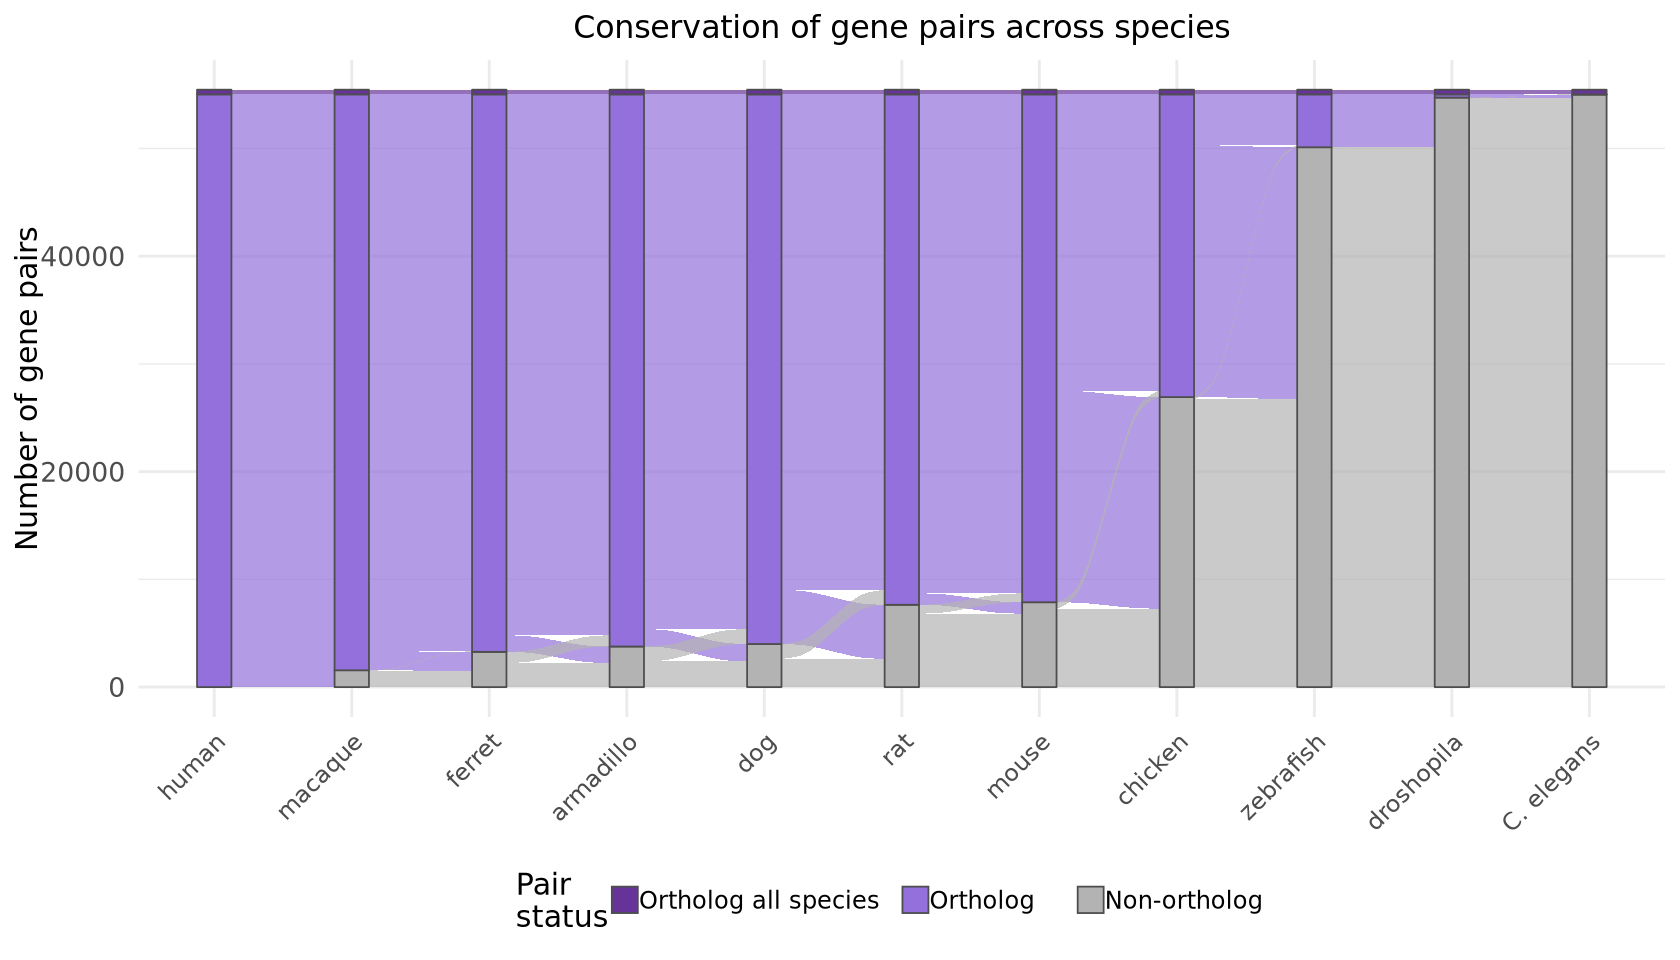

In [55]:
options(repr.plot.width=14, repr.plot.height=8)
# Create plot for gene pairs
if (!is.null(pair_alluvial)) {
    pair_plot <- create_alluvial_plot(pair_alluvial, "gene_pair")
    if (!is.null(pair_plot)) {
        print(pair_plot)
    }
}

### Save plot

In [56]:
# Save the gene pair conservation plot
ggsave(filename = file.path(out_dir, paste0("Gene_pair_orthologs_", date, ".pdf")),
    plot = pair_plot, 
    width = width * 0.6, height = height, units = "in", dpi = dpi)

Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”


In [57]:
out_dir

[1] "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/04_Figure_window_size_and_GO/06_Species_comparison_lncRNA_TF/Plots/"

Let's save the pair genes conserv for further analyses

In [58]:
# Get the number of species columns that a gene pair is conserved in
tmp_conservation <- pair_conservation$data %>%
    mutate(num_species_conserved = rowSums(across(-region, ~ . == "Present")))

table(tmp_conservation$num_species_conserved)
summary(tmp_conservation$num_species_conserved)


    1     2     3     4     5     6     7     8     9    10    11 
 1470   548   342   934  4045  2504 18342 22446  4076   313   431 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   7.000   7.000   7.125   8.000  11.000 

Most pairs are conserved across around 8 species. For downstream analysis, let's save the transcript ids of conserved pairs. For comparison, let's save those not present in all df and those only found in one dataset

In [59]:
# Get the conserved gene pairs ids
conserved_pairs <- tmp_conservation %>%
    filter(num_species_conserved == (ncol(tmp_conservation) - 2)) %>%
    pull(region)

# Get the other regions
other_pairs <- tmp_conservation %>%
    filter(num_species_conserved > 1 & num_species_conserved < (ncol(tmp_conservation) - 2)) %>%
    pull(region)

# Get the human specific gene pairs data
human_specific_pairs <- tmp_conservation %>%
    filter(num_species_conserved == 1) %>%
    pull(region)

cat("Number of gene pairs conserved in all species: ", length(conserved_pairs), "\n")
cat("Number of gene pairs conserved in some but not all species: ", length(other_pairs), "\n")
cat("Number of human specific gene pairs: ", length(human_specific_pairs), "\n")

Number of gene pairs conserved in all species:  431 
Number of gene pairs conserved in some but not all species:  53550 
Number of human specific gene pairs:  1470 


Let's recover the gene_id of TF on each conservation group

In [60]:
# Let's add region information to the gene pairs to select information
gene_pairs <- gene_pairs %>%
    mutate(pair_id = paste(ncRNA_id, pcg_id, sep = "_"))

In [61]:
head(gene_pairs, 3)

,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF,abs_strand_distance,pair_id
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>,<int>,<chr>
1,11,ENST00000244906,61757671,MYRF-AS1,-1,lncRNA,ENST00000265460,MYRF,61755389,-2282,2282,NDT80_PhoG,TRUE,2282,ENST00000244906_ENST00000265460
2,17,ENST00000285274,18682228,ZNF286B,-1,lncRNA,ENST00000454745,FOXO3B,18682262,34,-34,Fork_head,TRUE,34,ENST00000285274_ENST00000454745
3,5,ENST00000297163,136134890,SMAD5-AS1,-1,lncRNA,ENST00000506223,SMAD5,136133823,-1067,1067,MH1,TRUE,1067,ENST00000297163_ENST00000506223


In [62]:
# For GO analysese, let's save the IDs of TFs according to the conservation groups
human_specific_TFs <- gene_pairs %>%
    filter(pair_id %in% human_specific_pairs) %>%
    pull(pcg_id) %>% unique()

conserved_TFs <- gene_pairs %>%
    filter(pair_id %in% conserved_pairs) %>%
    pull(pcg_id) %>% unique()
    
other_TFs <- gene_pairs %>%
    filter(pair_id %in% other_pairs) %>%
    pull(pcg_id) %>% unique()

cat("Number of human specific TFs: ", length(human_specific_TFs), "\n")
cat("Number of conserved TFs: ", length(conserved_TFs), "\n")
cat("Number of other TFs: ", length(other_TFs), "\n")

Number of human specific TFs:  31 
Number of conserved TFs:  4 
Number of other TFs:  1898 


In [63]:
# Conserved TF gene names
conserved_TF_names <- gene_pairs %>%
    filter(pair_id %in% conserved_pairs) %>%
    select(pcg_id, pcg_gene_name) %>%
    distinct()

human_specific_TF_names <- gene_pairs %>%
    filter(pair_id %in% human_specific_pairs) %>%
    select(pcg_id, pcg_gene_name) %>%
    distinct()

conserved_TF_names

pcg_id,pcg_gene_name
<chr>,<chr>
ENST00000716043,
ENST00000700211,NR2F1
ENST00000560160,SIX5
ENST00000335071,FOXE3


In [19]:
human_specific_TF_names %>% filter(pcg_gene_name != "")

pcg_id,pcg_gene_name
<chr>,<chr>
ENST00000441888,POU5F1
ENST00000306910,ZNF584
ENST00000587340,ZSCAN5A
ENST00000426488,ZNF668
ENST00000651332,ZNF257
ENST00000972183,ZNF813
ENST00000897545,ZNF561
ENST00000956250,RHOXF1
ENST00000566718,MGA


In [ ]:
# Save supplementary table with ID and TF name
write.table(conserved_TF_names,
            file = file.path(supplementary_folder, paste0("Supplementary_table_conserved_TFs_", date, ".tsv")),
            sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)
write.table(human_specific_TF_names,
            file = file.path(supplementary_folder, paste0("Supplementary_table_human_specific_TFs_", date, ".tsv")),
            sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)

In [20]:
# Save the TF IDs for GO analysis
write.table(human_specific_TFs, file = file.path(out_dir, paste0("Human_specific_TFs_", date, ".txt")),
            quote = FALSE, row.names = FALSE, col.names = FALSE)
write.table(conserved_TFs, file = file.path(out_dir, paste0("Conserved_TFs_", date, ".txt")),
            quote = FALSE, row.names = FALSE, col.names = FALSE)
write.table(other_TFs, file = file.path(out_dir, paste0("Other_TFs_", date, ".txt")),
            quote = FALSE, row.names = FALSE, col.names = FALSE)

For motif analysis, let's recover the TSS and set a fixed 1000 bp region around them 

In [27]:
fixed_region_size = 1000  # 1 kb regions around TSS
human_specific_tss <- gene_pairs %>%
    filter(pair_id %in% human_specific_pairs) %>%
    select(ncrna_tss, pcg_tss, chromosome) %>%
    distinct()
human_specific_tss <- data.frame(chromosome = paste0("chr", c(human_specific_tss$chromosome, human_specific_tss$chromosome)),
                                tss = c(human_specific_tss$ncrna_tss, human_specific_tss$pcg_tss)) %>%
                                mutate(start = tss - fixed_region_size / 2,
                                       end = tss + fixed_region_size / 2) %>%
                                select(chromosome, start, end) %>% distinct()

conserved_tss <- gene_pairs %>%
    filter(pair_id %in% conserved_pairs) %>%
    select(ncrna_tss, pcg_tss, chromosome) %>%
    distinct()

conserved_tss <- data.frame(chromosome = paste0("chr", c(conserved_tss$chromosome, conserved_tss$chromosome)),
                                tss = c(conserved_tss$ncrna_tss, conserved_tss$pcg_tss)) %>%
                                mutate(start = tss - fixed_region_size / 2,
                                       end = tss + fixed_region_size / 2) %>%
                                select(chromosome, start, end) %>% distinct()

other_tss <- gene_pairs %>%
    filter(pair_id %in% other_pairs) %>%
    select(ncrna_tss, pcg_tss, chromosome) %>%
    distinct()

other_tss <- data.frame(chromosome = paste0("chr", c(other_tss$chromosome, other_tss$chromosome)),
                                tss = c(other_tss$ncrna_tss, other_tss$pcg_tss)) %>%
                                mutate(start = tss - fixed_region_size / 2,
                                       end = tss + fixed_region_size / 2) %>%
                                select(chromosome, start, end) %>% distinct()

In [28]:
head(human_specific_tss, 3)

,chromosome,start,end
,<chr>,<dbl>,<dbl>
1,chr21,33930634,33931634
2,chr6,31185618,31186618
3,chr21,33930613,33931613


In [29]:
# Save the TSS regions for motif analysis
write.table(human_specific_tss, file = file.path(out_dir, paste0("Human_specific_TSS_regions_", date, ".bed")),
            quote = FALSE, row.names = FALSE, col.names = FALSE, sep = "\t")
write.table(conserved_tss, file = file.path(out_dir, paste0("Conserved_TSS_regions_", date, ".bed")),
            quote = FALSE, row.names = FALSE, col.names = FALSE, sep = "\t")
write.table(other_tss, file = file.path(out_dir, paste0("Other_TSS_regions_", date  , ".bed")),
            quote = FALSE, row.names = FALSE, col.names = FALSE, sep = "\t")